Task 1 : Vectorized Multi-Layer Perceptron (MLP) Forward & Backward
Pass from Scratch

In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [15]:
# 1. Create simple dataset
X = np.random.randn(300, 2)

# 3 classes
y = np.where(X[:, 0] + X[:, 1] > 1, 0,
    np.where(X[:, 0] - X[:, 1] > 0, 1, 2))

# One-hot encoding
Y = np.eye(3)[y]


In [24]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# 2. Initialize weights
W1 = np.random.randn(2, 10) * 0.1
b1 = np.zeros((1, 10))

W2 = np.random.randn(10, 3) * 0.1
b2 = np.zeros((1, 3))

learning_rate = 0.1
epochs = 500

losses = []


In [18]:
# 3. ReLU
def relu(x):
    return np.maximum(0, x)

In [19]:
# 4. Softmax
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)



In [22]:
# 5. Training
for epoch in range(epochs):

    # Forward Pass

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    # Cross Entropy Loss

    loss = -np.mean(
        np.sum(Y * np.log(A2 + 1e-8), axis=1)
    )

    losses.append(loss)

    # Backward Pass

    dZ2 = (A2 - Y) / len(X)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * (Z1 > 0)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update Weights

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(
            "Epoch:",
            epoch + 1,
            "Loss:",
            round(loss, 4)
        )

Epoch: 50 Loss: 0.9568
Epoch: 100 Loss: 0.4816
Epoch: 150 Loss: 0.277
Epoch: 200 Loss: 0.2166
Epoch: 250 Loss: 0.1883
Epoch: 300 Loss: 0.1709
Epoch: 350 Loss: 0.1585
Epoch: 400 Loss: 0.1487
Epoch: 450 Loss: 0.1406
Epoch: 500 Loss: 0.1337


### 6. Evaluate Model Performance

In [25]:
def evaluate(X_eval, y_eval, W1, b1, W2, b2):
    # Forward pass
    Z1_eval = X_eval @ W1 + b1
    A1_eval = relu(Z1_eval)
    Z2_eval = A1_eval @ W2 + b2
    A2_eval = softmax(Z2_eval)

    # Get predictions (class with highest probability)
    predictions = np.argmax(A2_eval, axis=1)

    # Calculate accuracy
    accuracy = np.mean(predictions == y_eval)
    return accuracy

# Evaluate the model on the test dataset
test_accuracy = evaluate(X_test, y_test, W1, b1, W2, b2)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 98.33%


In [26]:
 #  Update Weights
W2 -= learning_rate * dW2
b2 -= learning_rate * db2
W1 -= learning_rate * dW1
b1 -= learning_rate * db1


In [27]:
 # Print loss
if (epoch + 1) % 50 == 0:
        print(
            "Epoch:",
            epoch + 1,
            "Loss:",
            round(loss, 4)
        )


Epoch: 500 Loss: 0.1337


In [28]:
# 6. Prediction
predictions = np.argmax(A2, axis=1)

accuracy = np.mean(predictions == y)

print("\nFinal Accuracy:",
      round(accuracy * 100, 2), "%")



Final Accuracy: 96.67 %


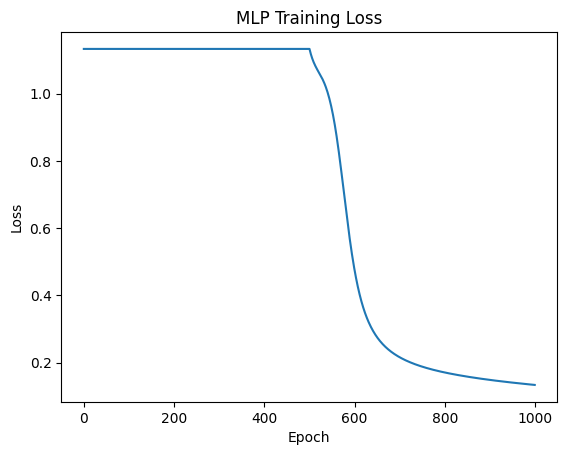

In [29]:
 #7. Plot Loss
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")

plt.show()